# 03_economic_analysis.ipynb
## Project: Malaysia Unemployment Analysis
### Notebook 03: Economic Insights, Okun’s Law & Policy Recommendations
**Author:** Tze Ping  
**Date:** March 2026  
**Target:** Data Analysis Internship (Economics background)  
**Description:** Testing Okun’s Law, ASEAN comparison, regression analysis, and real policy recommendations.

In [178]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress

# ====================== CONFIG ======================
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

plt.style.use('seaborn-v0_8-whitegrid')

# ====================== PATHS ======================
ROOT = Path.cwd()
DATA_PROCESSED = ROOT / "data" / "processed"
IMAGE_DIR_03 = ROOT / "image_chart_03_economic_analysis"
IMAGE_DIR_03.mkdir(parents=True, exist_ok=True)

print(" Environment ready for economic analysis!")

 Environment ready for economic analysis!


In [179]:
# Load Malaysia & Global 10 Years(2012-2022) Data Frame(for ASEAN comparison)
df_malaysia = pd.read_csv(DATA_PROCESSED / "malaysia_clean.csv")
df_global = pd.read_csv(DATA_PROCESSED / "global_clean.csv")

print(f"Malaysia data: {df_malaysia.shape[0]} rows x {df_global.shape[1]} colunms ")
print(f"Global data: {df_global.shape[0]} rows x {df_global.shape[1]} colunms")

Malaysia data: 32 rows x 7 colunms 
Global data: 5751 rows x 7 colunms


In [180]:
# Calculate year-over-year GDP growth (%)
df_malaysia = df_malaysia.sort_values('Year')
df_malaysia['GDP_growth'] = df_malaysia['GDP (billion USD)'].pct_change() * 100

print("new column GDP Growth added. First 5 rows:")
display(df_malaysia[['Year', 'GDP (billion USD)', 'GDP_growth', 'Unemployment Rate']].head())

new column GDP Growth added. First 5 rows:


,Year,GDP (billion USD),GDP_growth,Unemployment Rate
0,1991,49.14,NaN,3.70
1,1992,59.17,20.41,3.71
2,1993,66.89,13.05,4.11
3,1994,74.48,11.35,3.64
4,1995,88.71,19.11,3.15


OKUN’S LAW REGRESSION RESULTS
Slope (β)       : -0.001   → For every 1% GDP growth, unemployment changes by -0.001%
Intercept       : 3.414
R-squared       : 0.000 (0.0% of variation explained)
p-vlue          : 0.9116
Fail to reject and statistically signficant


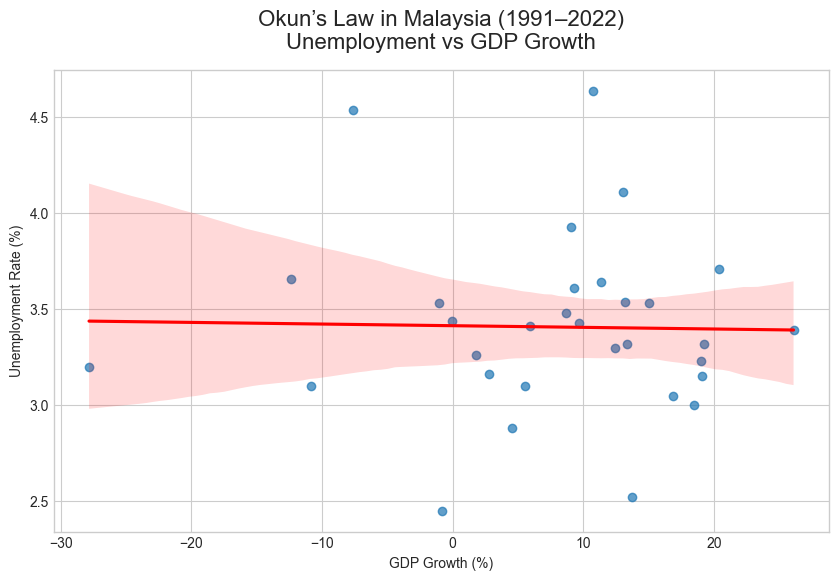

In [181]:
# ====================== 4. Okun’s Law Regression + Scatter Plot ======================
# Drop NaNs together so x and y have the same rows
df_reg = df_malaysia.dropna(subset=['GDP_growth', 'Unemployment Rate']).copy()

### rmb to dropna together for x column and y column ,
# dont drop seperately will occur diferent number of rows##
#becaz if u drop the Unemrployment column which has no Nan ,
# therefore ramain but GDP_growth has NaN so will remove one row 

x = df_reg['GDP_growth']
y = df_reg['Unemployment Rate']

### lineregress(x,y) is for data info
### sns.regplot is for scatter plot
result = linregress(x, y)

print("OKUN’S LAW REGRESSION RESULTS")
print(f"Slope (β)       : {result.slope:.3f}   → For every 1% GDP growth, unemployment changes by {result.slope:.3f}%")
print(f"Intercept       : {result.intercept:.3f}")
print(f"R-squared       : {result.rvalue**2:.3f} ({result.rvalue**2*100:.1f}% of variation explained)")
print(f"p-vlue          : {result.pvalue:.4f}")
P=result.pvalue
if P <0.005:
    print("Reject, and statistically significant")
else:
    print("Fail to reject and statistically signficant")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x=x, y=y, scatter_kws={'alpha':0.7}, line_kws={'color':'red'}, ax=ax)

ax.set_title("Okun’s Law in Malaysia (1991–2022)\nUnemployment vs GDP Growth", fontsize=16, pad=15)
ax.set_xlabel("GDP Growth (%)")
ax.set_ylabel("Unemployment Rate (%)")
plt.savefig(IMAGE_DIR_03 / "okun_law_regression.png", dpi=300)
plt.show()

# Time lag effect
## Today GDP affect Unemployment Rate later
### So we improve our model by using time lag effect ,shift the previous year to current year


OKUN'S LAW REGRESSION RESULTS (WITH 1-YEAR LAG)
Slope (β)          : -0.0089
Intercept          : 3.4658
R-squared          : 0.0474
p-value            : 0.2477

Conclusion: NOT statistically significant  (Fail to reject H0)


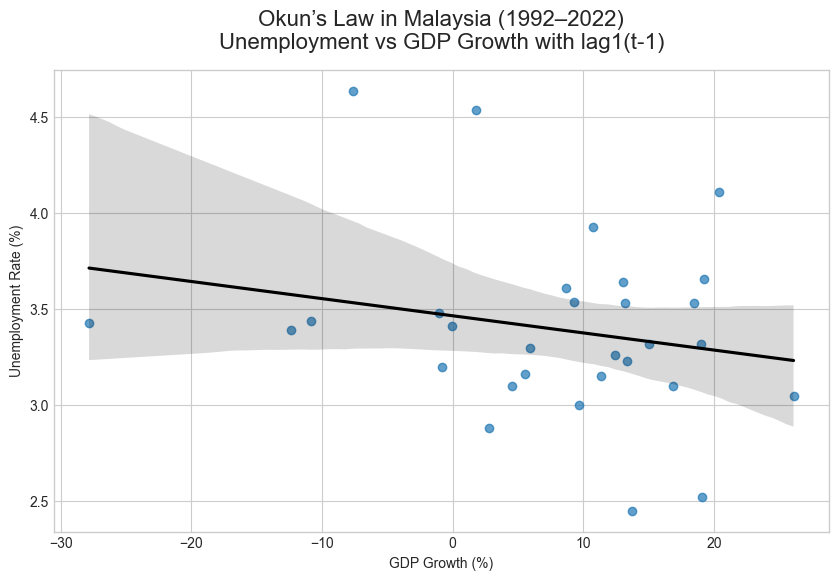

In [182]:
# ====================== OKUN'S LAW (WITH LAG) ======================

# 1. Prepare data (select relevant columns & drop NA together)
df_okun = df_malaysia.dropna()[['Year', 'GDP_growth', 'Unemployment Rate']].copy()
df_okun = df_okun.sort_values('Year').reset_index(drop=True) ###sort_value("column").reset_index(drop=True)

# 2. Create lagged GDP (GDP from previous year)
df_okun['GDP_growth_lag1'] = df_okun['GDP_growth'].shift(1) ###shift 1 means move down the row
### so the first year of GDP growth will Nan,shift 1 is moveto right or down

# 3. Drop NA after lagging
df_okun = df_okun.dropna() ###the whole row which have NaN will be remove###

# 4. Define variables
x = df_okun['GDP_growth_lag1']
y = df_okun['Unemployment Rate']

# 5. Run regression
result = linregress(x, y)

# 6. Print results
print("OKUN'S LAW REGRESSION RESULTS (WITH 1-YEAR LAG)")
print(f"Slope (β)          : {result.slope:.4f}")
print(f"Intercept          : {result.intercept:.4f}")
print(f"R-squared          : {result.rvalue**2:.4f}")
print(f"p-value            : {result.pvalue:.4f}")

# 7. Interpretation
if result.pvalue < 0.05:
    print("\nConclusion: Statistically significant relationship ")
else:
    print("\nConclusion: NOT statistically significant  (Fail to reject H0)")

#Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x=x, y=y, scatter_kws={'alpha':0.7}, line_kws={'color':'black'}, ax=ax)

ax.set_title("Okun’s Law in Malaysia (1992–2022)\nUnemployment vs GDP Growth with lag1(t-1)", fontsize=16, pad=15)
ax.set_xlabel("GDP Growth (%)")
ax.set_ylabel("Unemployment Rate (%)")
plt.savefig(IMAGE_DIR_03 / "okun_law_regression_lag1(t-1).png", dpi=300)
plt.show()

ASEAN Unemployment Rate (2010–2022 average):


Country Name
Thailand      0.73
Philippines   3.02
Malaysia      3.48
Singapore     3.88
Indonesia     4.29
Name: Unemployment Rate, dtype: float64

C:\Users\tay27\AppData\Local\Temp\ipykernel_17328\1115142919.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=recent_avg.reset_index(), x='Country Name', y='Unemployment Rate', palette='coolwarm')


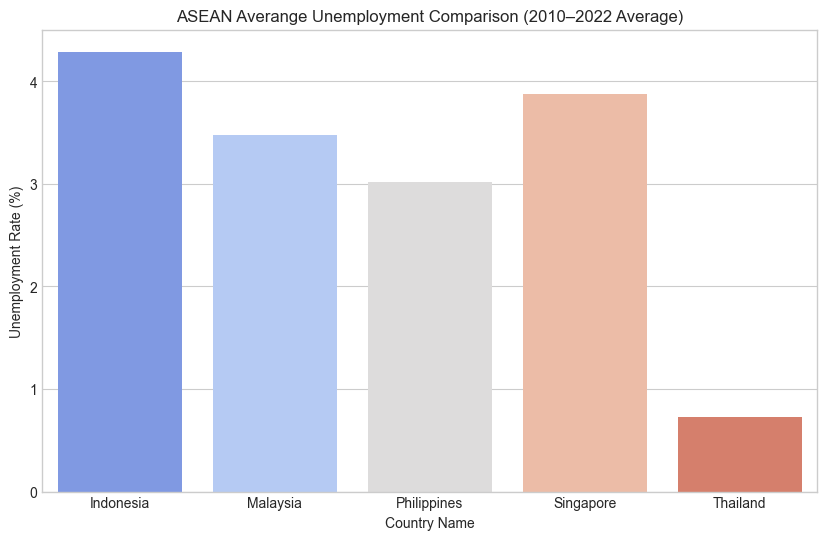

In [183]:
# Select ASEAN countries for comparison
asean_countries = ['Malaysia', 'Singapore', 'Thailand', 'Indonesia', 'Philippines']
df_asean = df_global[df_global['Country Name'].isin(asean_countries)].copy()

# Average unemployment by country (post-2010 for recent view)
#So here we analysis averange unemployment recent which is 2010-2022 for ASEAN
recent_avg = df_asean[df_asean['Year'] >= 2010].groupby('Country Name')['Unemployment Rate'].mean().round(2)
print("ASEAN Unemployment Rate (2010–2022 average):")
display(recent_avg.sort_values())

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=recent_avg.reset_index(), x='Country Name', y='Unemployment Rate', palette='coolwarm')
ax.set_title("ASEAN Averange Unemployment Comparison (2010–2022 Average)")
ax.set_ylabel("Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.savefig(IMAGE_DIR_03 / "asean_comparison.png", dpi=300)
plt.show()